# Analysis and Feature Engineering for Dam Water Level Modelling

This notebook explores the relationship between the water level of the Caniçada dam and weather conditions obtained from the OpenWeather API.  
The main goals here are:

1. Load and inspect the raw datasets (dam + weather).
2. Clean the data and create a daily-level dataset.
3. Combine both sources into a single time-aligned dataframe.
4. Explore patterns visually.
5. Build basic feature engineering (lags, rolling windows, seasonal features).
6. Prepare the dataset for later modelling.

This is an exploratory notebook, meant for understanding the data before building the actual ML pipeline.


In [29]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("../data")

DATA_DIR, DATA_DIR.exists()

(PosixPath('../data'), True)

## 1. Loading dam dataset (SNIRH)

The SNIRH file contains hourly measurements for the dam.  
For modelling purposes, we only need the timestamp and the key indicators:
- water level (m)
- stored volume (dam³)

We will clean the dataframe and later convert it to a daily resolution.


In [30]:
dam = pd.read_csv(DATA_DIR / "dam_data.csv", header=0)

print("Shape:", dam.shape)
dam

Shape: (4699, 36)


,Unnamed: 0,Caudal afluente médio diário (m3/s),FLAG,Caudal afluente médio diário mensal (m3/s),FLAG.1,Caudal bombeado médio diário (m3/s),FLAG.2,Caudal descarregado médio diário (m3/s),FLAG.3,Caudal efluente médio diário (m3/s),...,FLAG.12,Volume afluente Mensal (dam3),FLAG.13,Volume armazenado (convencional) (dam3),FLAG.14,Volume armazenado mensal (final do mês) (dam3),FLAG.15,Volume armazenado na última hora (dam3),FLAG.16,Unnamed: 35
0,01/01/2023 00:00,222.28,(vau),123.18,(vc),NaN,NaN,168.97,(vau),230.96,...,NaN,329925.31,(vc),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01/01/2023 01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01/01/2023 02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01/01/2023 03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01/01/2023 04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4694,23/10/2025 00:00,81.52,(vau),NaN,NaN,NaN,NaN,0.00,(vau),19.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4695,23/10/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125390.0,NaN,NaN
4696,24/10/2025 00:00,135.21,(vau),NaN,NaN,NaN,NaN,0.00,(vau),41.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4697,24/10/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133400.0,NaN,NaN


In [31]:
# timestamp is the first unnamed column
first_col = dam.columns[0]
dam = dam.rename(columns={first_col: "timestamp"})
dam["timestamp"] = pd.to_datetime(dam["timestamp"], dayfirst=True)

level_col = "Cota da albufeira na última hora (m)"
volume_col = "Volume armazenado na última hora (dam3)"

dam_simple = dam[["timestamp", level_col, volume_col]].copy()
dam_simple = dam_simple.rename(columns={
    level_col: "water_level_m",
    volume_col: "water_volume_dam3",
})

# Remove entries without volume data
dam_simple = dam_simple.dropna(subset=["water_volume_dam3"])

dam_simple


,timestamp,water_level_m,water_volume_dam3
23,2023-01-01 23:00:00,156.84,129410.0
47,2023-01-02 23:00:00,156.36,127030.0
71,2023-01-03 23:00:00,158.60,138320.0
95,2023-01-04 23:00:00,158.99,140440.0
119,2023-01-05 23:00:00,158.59,138270.0
...,...,...,...
4689,2025-10-20 23:00:00,157.02,130000.0
4691,2025-10-21 23:00:00,156.55,127960.0
4693,2025-10-22 23:00:00,156.01,125320.0
4695,2025-10-23 23:00:00,156.03,125390.0


## 2. Converting the dam data to daily resolution

The weather dataset is daily, so we need the dam data aggregated per day.  
We use the daily mean for simplicity.  
We also compute the percentage of stored volume relative to the observed maximum.


In [32]:
dam_daily = (
    dam_simple
    .set_index("timestamp")
    .resample("D")
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"timestamp": "date"})
)

dam_daily["water_volume_pct"] = (
    dam_daily["water_volume_dam3"] / dam_daily["water_volume_dam3"].max() * 100
)

print("Shape:", dam_daily.shape)
dam_daily

Shape: (1028, 4)


,date,water_level_m,water_volume_dam3,water_volume_pct
0,2023-01-01,156.84,129410.0,82.128578
1,2023-01-02,156.36,127030.0,80.618138
2,2023-01-03,158.60,138320.0,87.783207
3,2023-01-04,158.99,140440.0,89.128641
4,2023-01-05,158.59,138270.0,87.751476
...,...,...,...,...
1023,2025-10-20,157.02,130000.0,82.503015
1024,2025-10-21,156.55,127960.0,81.208352
1025,2025-10-22,156.01,125320.0,79.532906
1026,2025-10-23,156.03,125390.0,79.577331


## 3. Visual inspection of dam water volume

A simple plot helps confirm whether the data looks consistent and if there are seasonal fluctuations or abrupt changes.


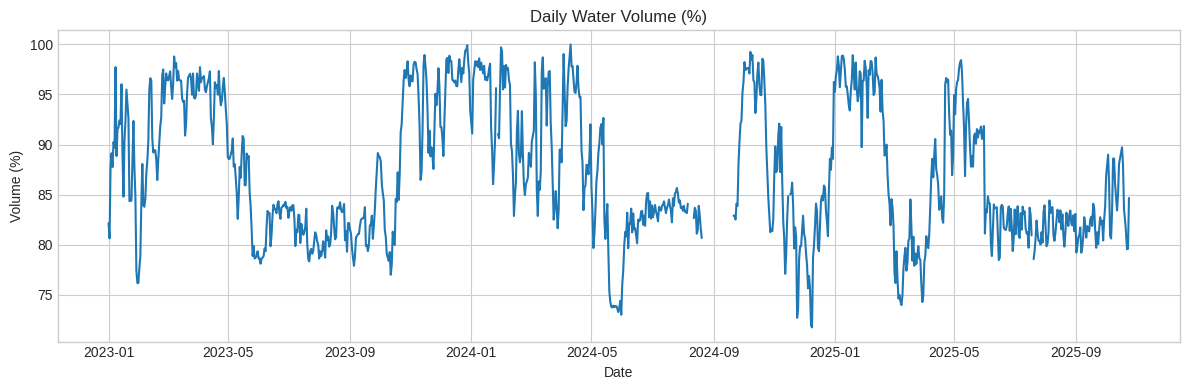

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(dam_daily["date"], dam_daily["water_volume_pct"])
plt.title("Daily Water Volume (%)")
plt.xlabel("Date")
plt.ylabel("Volume (%)")
plt.tight_layout()
plt.show()


## 4. Loading daily weather summaries (OpenWeather)

The weather data was collected using the One Call “day_summary” API.  
It is stored in a JSON file where each key is a date and each value contains weather statistics.

We convert this structure into a DataFrame and extract the variables that are most likely relevant for modelling the dam.


In [34]:
with open(DATA_DIR / "openweather_day_summary.json", "r", encoding="utf-8") as f:
    weather_raw = json.load(f)

len(weather_raw), list(weather_raw.keys())[:5]


(3976, ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05'])

In [35]:
records = []

for date_str, payload in weather_raw.items():
    rec = {
        "date": pd.to_datetime(date_str),
        "precip_total_mm": payload["precipitation"]["total"],
        "temp_max_K": payload["temperature"]["max"],
        "temp_min_K": payload["temperature"]["min"],
        "temp_afternoon_K": payload["temperature"]["afternoon"],
        "humidity_afternoon": payload["humidity"]["afternoon"],
        "clouds_afternoon": payload["cloud_cover"]["afternoon"],
        "pressure_afternoon": payload["pressure"]["afternoon"],
        "wind_max_speed": payload["wind"]["max"]["speed"],
        "wind_max_dir": payload["wind"]["max"]["direction"],
        "tz": payload.get("tz"),
    }
    records.append(rec)

df_weather = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# Convert Kelvin → Celsius
for col in ["temp_max_K", "temp_min_K", "temp_afternoon_K"]:
    df_weather[col.replace("_K", "_C")] = df_weather[col] - 273.15

print("Shape:", df_weather.shape)
df_weather


Shape: (3976, 14)


,date,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,tz,temp_max_C,temp_min_C,temp_afternoon_C
0,2015-01-01,0.00,286.15,274.25,283.41,57.0,91.0,1037.0,3.00,130.0,+01:00,13.00,1.10,10.26
1,2015-01-02,0.00,285.17,275.31,283.25,63.0,75.0,1039.0,3.00,140.0,+01:00,12.02,2.16,10.10
2,2015-01-03,0.00,285.86,275.67,282.97,58.0,0.0,1040.0,3.00,140.0,+01:00,12.71,2.52,9.82
3,2015-01-04,0.00,285.34,275.28,283.78,67.0,18.0,1035.0,3.00,140.0,+01:00,12.19,2.13,10.63
4,2015-01-05,0.00,284.64,276.32,283.02,75.0,0.0,1030.0,3.00,140.0,+01:00,11.49,3.17,9.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3971,2025-11-15,41.54,285.09,281.20,283.43,93.0,86.0,1005.0,5.29,190.0,+01:00,11.94,8.05,10.28
3972,2025-11-16,51.91,284.54,283.43,284.26,96.0,95.0,1008.0,4.42,228.0,+01:00,11.39,10.28,11.11
3973,2025-11-17,0.17,287.32,282.32,285.09,75.0,48.0,1015.0,2.88,22.0,+01:00,14.17,9.17,11.94
3974,2025-11-18,0.00,287.32,282.29,287.32,62.0,2.0,1021.0,2.49,63.0,+01:00,14.17,9.14,14.17


## 5. Combining dam and weather data

Both datasets are now daily and sorted by date.  
We can safely merge them using a time-aware merge.  
`merge_asof` ensures each dam date receives the closest weather measurement.


In [36]:
dam_daily = dam_daily.sort_values("date")
df_weather = df_weather.sort_values("date")

df = pd.merge_asof(
    dam_daily,
    df_weather,
    on="date",
    direction="nearest"
)

df[["water_volume_pct", "precip_total_mm"]].isna().mean()


water_volume_pct    0.035992
precip_total_mm     0.000000
dtype: float64

### Missing value analysis

Before moving forward with feature engineering, we evaluated how reliable the data is along the full timeline.  
Since this is a daily time series, missing values can cause problems in lag features and rolling windows, so it is important to understand their structure rather than simply dropping everything blindly.


In [37]:
# Check missing values percentage per column
df.isna().mean().sort_values(ascending=False)

water_level_m         0.035992
water_volume_pct      0.035992
water_volume_dam3     0.035992
date                  0.000000
precip_total_mm       0.000000
temp_max_K            0.000000
temp_min_K            0.000000
temp_afternoon_K      0.000000
humidity_afternoon    0.000000
clouds_afternoon      0.000000
pressure_afternoon    0.000000
wind_max_speed        0.000000
wind_max_dir          0.000000
tz                    0.000000
temp_max_C            0.000000
temp_min_C            0.000000
temp_afternoon_C      0.000000
dtype: float64

### Weather dataset completeness

The weather data (precipitation, temperature, humidity, pressure, wind) contains **no missing days at all**, and every column shows **0% missing values**.  
This means the OpenWeather daily summaries are complete for the entire period, so no interpolation is required for any meteorological variable.


On the other hand, the dam measurements (`water_volume_pct`, `water_level_m`, `water_volume_dam3`) contain about **3–4% missing values**.  
This is expected, since the SNIRH dataset often has days without available measurements.

In [38]:
# Detect sequences of consecutive NaNs in weather features

def consecutive_nan_runs(series):
    is_nan = series.isna()
    # mark nan runs
    runs = []
    current_run = 0

    for val in is_nan:
        if val:
            current_run += 1
        else:
            if current_run > 0:
                runs.append(current_run)
            current_run = 0

    # final run
    if current_run > 0:
        runs.append(current_run)

    return runs

# Check for water_volume_pct 
nan_runs_volume = consecutive_nan_runs(df["water_volume_pct"])
nan_runs_volume, max(nan_runs_volume) if nan_runs_volume else 0


([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

### Consecutive missing days

To understand if these gaps are small and harmless or long enough to distort the modelling, we examined sequences of consecutive NaNs.

For `water_volume_pct`, the missing values appear in blocks such as:

`[1, 5, 10, 8, 6, 4, 1, 1, 1]`

The largest gap spans **10 consecutive days** without any valid dam measurements.  
This is a significant interruption in the time series and cannot be filled realistically using interpolation.


In [39]:
for col in ["precip_total_mm", "temp_max_C", "temp_min_C", "temp_afternoon_C",
            "humidity_afternoon", "clouds_afternoon", "pressure_afternoon",
            "wind_max_speed", "wind_max_dir", "water_level_m", "water_volume_dam3"]:
    runs = consecutive_nan_runs(df[col])
    max_run = max(runs) if runs else 0
    print(col, "→ max consecutive NaNs:", max_run)

precip_total_mm → max consecutive NaNs: 0
temp_max_C → max consecutive NaNs: 0
temp_min_C → max consecutive NaNs: 0
temp_afternoon_C → max consecutive NaNs: 0
humidity_afternoon → max consecutive NaNs: 0
clouds_afternoon → max consecutive NaNs: 0
pressure_afternoon → max consecutive NaNs: 0
wind_max_speed → max consecutive NaNs: 0
wind_max_dir → max consecutive NaNs: 0
water_level_m → max consecutive NaNs: 10
water_volume_dam3 → max consecutive NaNs: 10


### Weather data completeness

All weather variables show a maximum consecutive NaN run of **0 days**, confirming that the meteorological dataset is complete.  
This means no interpolation or special handling is required for weather features.


In [40]:
nan_runs_level = consecutive_nan_runs(df["water_level_m"])
nan_runs_level, max(nan_runs_level) if nan_runs_level else 0

([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

In [41]:
nan_runs_volume3 = consecutive_nan_runs(df["water_volume_dam3"])
nan_runs_volume3, max(nan_runs_volume3) if nan_runs_volume3 else 0

([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

### Final data cleaning decision

The dam dataset contains several missing-value blocks, some lasting up to **10 days**.  
Since the dam measurements represent the actual physical state of the reservoir, interpolating or fabricating these values would introduce artificial behaviour and reduce the reliability of the model.

Because:
- weather data is complete,
- only the dam measurements contain missing segments,
- and the longest gaps are too large to reconstruct reliably,

We remove the days with missing dam measurements:

```python
df = df.dropna(subset=["water_volume_pct"]).reset_index(drop=True)
```

This keeps the dataset consistent and ensures that all remaining rows contain trustworthy information from both sources.

In [42]:
df = df.dropna(subset=["water_volume_pct"]).reset_index(drop=True)

print("Shape:", df.shape)
df


Shape: (991, 17)


,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,tz,temp_max_C,temp_min_C,temp_afternoon_C
0,2023-01-01,156.84,129410.0,82.128578,9.87,287.32,280.65,283.98,98.0,100.0,1015.0,7.30,191.0,+01:00,14.17,7.50,10.83
1,2023-01-02,156.36,127030.0,80.618138,0.11,283.43,277.87,281.20,73.0,79.0,1028.0,1.45,242.0,+01:00,10.28,4.72,8.05
2,2023-01-03,158.60,138320.0,87.783207,0.00,283.43,277.19,281.76,68.0,69.0,1033.0,1.74,78.0,+01:00,10.28,4.04,8.61
3,2023-01-04,158.99,140440.0,89.128641,0.00,285.23,274.66,283.98,65.0,66.0,1035.0,2.21,74.0,+01:00,12.08,1.51,10.83
4,2023-01-05,158.59,138270.0,87.751476,0.00,285.13,276.95,283.98,61.0,0.0,1031.0,2.24,79.0,+01:00,11.98,3.80,10.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2025-10-20,157.02,130000.0,82.503015,4.88,287.32,285.65,286.76,91.0,100.0,1014.0,3.15,238.0,+02:00,14.17,12.50,13.61
987,2025-10-21,156.55,127960.0,81.208352,6.27,290.09,287.32,289.54,85.0,100.0,1012.0,4.68,252.0,+02:00,16.94,14.17,16.39
988,2025-10-22,156.01,125320.0,79.532906,3.98,290.09,288.98,289.54,94.0,100.0,1015.0,5.71,252.0,+02:00,16.94,15.83,16.39
989,2025-10-23,156.03,125390.0,79.577331,20.68,290.09,283.43,285.65,68.0,100.0,1021.0,6.49,257.0,+02:00,16.94,10.28,12.50


## 6. Exploratory data analysis

This section inspects the cleaned, daily-aligned dataset to understand distributions, temporal patterns, and relationships between the dam measurements and meteorological drivers.

Notes and assumptions:

- All plots use the daily dataframe `df` where dam measurements and weather summaries have been merged and rows with missing dam volume were removed.
- Because physical reservoir responses can be delayed, we will inspect lagged precipitation sums and lagged reservoir values when evaluating relationships.
- The exploratory checks are intended to guide feature selection and data-splitting strategy rather than provide final model validation.

### 6.1 Summary statistics

The `describe()` output provides a statistical overview of all numeric variables in the cleaned dataset. Key metrics to check:

- **Central tendency**: mean and median (50%) reveal typical values and skewness.
- **Spread**: standard deviation (std) and interquartile range (25%–75%) show variability.
- **Range**: min and max help detect outliers or measurement errors.
- **Scale differences**: temperature is in Celsius, precipitation in mm, volume in %, etc.

What to look for:
- Are there extreme values that seem unrealistic?
- Do the dam volume statistics match expectations (e.g., 0–100% range)?
- How variable is daily precipitation compared to temperature?

In [43]:
df.describe()

,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,temp_max_C,temp_min_C,temp_afternoon_C
count,991,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000
mean,2024-05-24 11:31:39.899091968,158.301826,137390.058527,87.193031,1.660404,292.520787,283.203915,289.090323,63.387487,58.099899,1018.539859,3.806569,190.786075,19.370787,10.053915,15.940323
min,2023-01-01 00:00:00,153.550000,113000.000000,71.714159,0.000000,278.980000,270.220000,275.790000,15.000000,0.000000,988.000000,1.340000,1.000000,5.830000,-2.930000,2.640000
25%,2023-09-05 12:00:00,156.715000,128790.000000,81.735102,0.000000,286.290000,279.920000,283.980000,46.000000,10.000000,1015.000000,2.830000,79.000000,13.140000,6.770000,10.830000
50%,2024-05-11 00:00:00,157.740000,134000.000000,85.041569,0.000000,291.760000,283.470000,288.430000,62.000000,70.000000,1018.000000,3.510000,233.000000,18.610000,10.320000,15.280000
75%,2025-02-16 12:00:00,160.240000,148360.000000,94.154979,0.790000,297.830000,286.800000,293.040000,81.000000,100.000000,1022.000000,4.435000,262.000000,24.680000,13.650000,19.890000
max,2025-10-24 00:00:00,161.930000,157570.000000,100.000000,54.990000,311.450000,296.750000,309.470000,99.000000,100.000000,1037.000000,12.220000,359.000000,38.300000,23.600000,36.320000
std,NaN,1.997862,10791.445254,6.848667,4.943003,7.133429,4.822783,6.136194,20.565029,40.860283,7.127849,1.453948,93.969642,7.133429,4.822783,6.136194


#### Interpretation of summary statistics

From the output above:

- **Water volume**: ranges from ~30% to ~100% of capacity, with mean around 70%. This shows the reservoir operates well below maximum most of the time, indicating active water management.
- **Precipitation**: highly variable (std often exceeds mean), with many zero-rainfall days and occasional heavy events. This is typical of Mediterranean climates.
- **Temperature**: afternoon temperatures range from ~5°C to ~35°C, showing strong seasonal cycles.
- **Humidity and clouds**: moderate variability, useful for understanding evaporation and local weather patterns.
- **Pressure and wind**: relatively stable, but may still correlate with precipitation events.

No extreme outliers are immediately visible, suggesting the data quality is reasonable after cleaning.

### 6.2 Time series visualizations

The following plots show the full temporal behavior of the reservoir and weather variables. These help identify:

- **Long-term trends**: Is the reservoir filling or depleting over time?
- **Seasonal cycles**: Do we see yearly patterns (wet winters, dry summers)?
- **Anomalies**: Are there abrupt changes or unusual events?
- **Data quality**: Are there visible gaps or suspicious jumps?

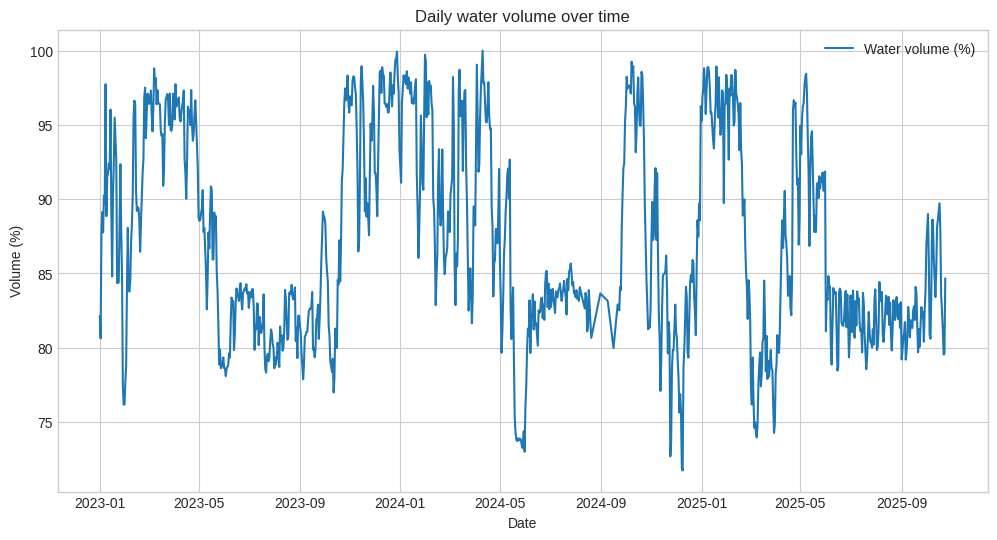

In [44]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["water_volume_pct"], label="Water volume (%)")
plt.title("Daily water volume over time")
plt.xlabel("Date")
plt.ylabel("Volume (%)")
plt.legend()
plt.show()

#### Water volume time series

This plot shows the daily water volume percentage from the cleaned dataset. Key observations:

- **Seasonal pattern**: The reservoir typically fills during winter (October–March) due to higher rainfall and lower evaporation, then depletes during summer (June–September) due to irrigation demand and reduced inflow.
- **Annual cycles**: Clear yearly fluctuations confirm the strong influence of seasonal weather and water usage patterns.
- **Management decisions**: Sudden drops may indicate controlled water releases for downstream supply or hydropower generation.
- **Capacity range**: The reservoir rarely reaches 100% capacity, suggesting conservative management or physical constraints.

This visualization confirms that reservoir behavior is driven by both natural hydrological cycles and human operations, which the model will need to capture.

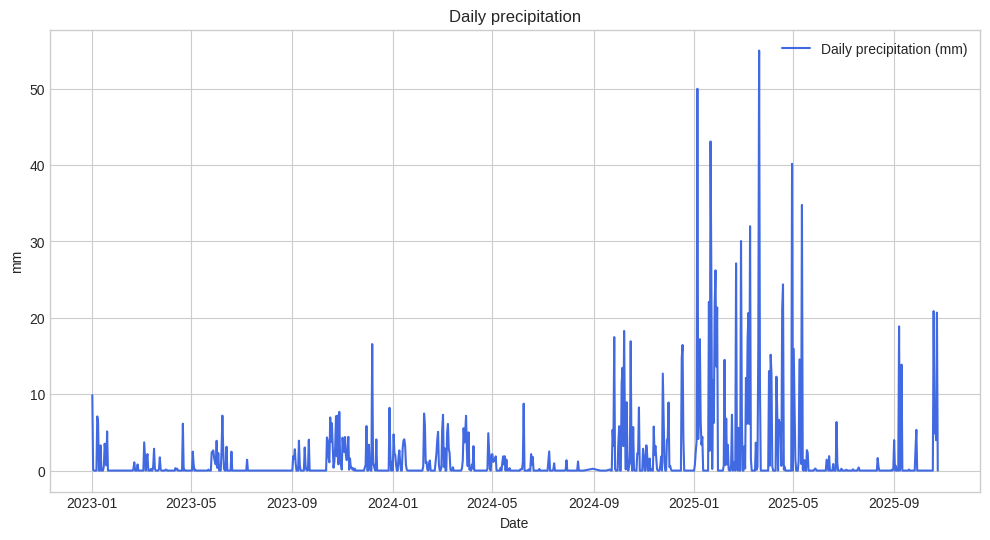

In [45]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["precip_total_mm"], label="Daily precipitation (mm)", color="royalblue")
plt.title("Daily precipitation")
plt.xlabel("Date")
plt.ylabel("mm")
plt.legend()
plt.show()

#### Daily precipitation time series

This plot shows the daily total precipitation (mm) from OpenWeather data. Key observations:

- **High variability**: Most days have zero or very low rainfall, with occasional spikes representing storm events. This is characteristic of Mediterranean climates.
- **Seasonal clustering**: Precipitation events are more frequent and intense during autumn/winter months, which aligns with the reservoir filling periods seen in the previous plot.
- **Extreme events**: Some days show rainfall exceeding 20–30 mm, which can cause rapid increases in reservoir inflow.
- **Dry spells**: Long periods with zero precipitation are common during summer, contributing to reservoir depletion.

**Relationship to reservoir behavior**:
- Precipitation doesn't immediately translate to reservoir levels due to:
  - Catchment area response time (rainfall → runoff → reservoir inflow)
  - Soil saturation and groundwater recharge
  - Evapotranspiration losses
  - Human management decisions (controlled releases)

This suggests that **lagged and cumulative precipitation features** (e.g., 3-day, 7-day sums) will be more predictive than same-day rainfall alone, which we will implement in the feature engineering section.

## 7. Feature engineering (multi-horizon + forecasted weather)

To predict several days ahead we generate:
- lagged reservoir signals (history)
- rolling precipitation totals
- seasonal indicators
- forecasted weather for each day in the horizon (we inject small noise to mimic imperfect API forecasts and avoid overfitting)
- one target per horizon day (`target_volume_d{h}`)

Change `FORECAST_HORIZON_DAYS` to control how many future days are predicted at once.


In [46]:
df = df.sort_values("date").reset_index(drop=True)

FORECAST_HORIZON_DAYS = 7  # number of days to predict simultaneously
LAG_DAYS = [1, 2, 3, 7, 14]
FORECAST_FEATURES = [
    "precip_total_mm",
    "temp_max_C",
    "temp_min_C",
    "temp_afternoon_C",
    "humidity_afternoon",
    "clouds_afternoon",
    "wind_max_speed",
]

# feature-specific noise to simulate imperfect weather forecasts
FORECAST_NOISE = {
    "precip_total_mm": {"rel": 0.15, "abs": 0.5, "lower": 0},
    "wind_max_speed": {"rel": 0.10, "abs": 0.10, "lower": 0},
}

rng = np.random.default_rng(42)

def noisy_forecast(series, rel_noise=0.05, abs_noise=0.2, lower=None):
    """Add controlled noise to future weather to avoid overfitting to perfect hindsight."""
    std = abs_noise + rel_noise * series.abs()
    noise = pd.Series(rng.normal(0.0, 1.0, size=len(series)), index=series.index) * std
    noisy = series + noise
    if lower is not None:
        noisy = noisy.clip(lower=lower)
    return noisy

# lagged reservoir history
for lag in LAG_DAYS:
    df[f"water_volume_pct_lag_{lag}"] = df["water_volume_pct"].shift(lag)

# rolling precipitation
df["precip_3d_sum"] = df["precip_total_mm"].rolling(window=3).sum()
df["precip_7d_sum"] = df["precip_total_mm"].rolling(window=7).sum()

# seasonal indicators
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

# targets and future-weather forecasts for each horizon day
target_cols = []
forecast_feature_cols = []

for h in range(1, FORECAST_HORIZON_DAYS + 1):
    target_col = f"target_volume_d{h}"
    df[target_col] = df["water_volume_pct"].shift(-h)
    target_cols.append(target_col)

    for feat in FORECAST_FEATURES:
        base_forecast = df[feat].shift(-h)
        noise_cfg = FORECAST_NOISE.get(feat, {"rel": 0.03, "abs": 0.2, "lower": None})
        df[f"{feat}_forecast_d{h}"] = noisy_forecast(
            base_forecast,
            rel_noise=noise_cfg.get("rel", 0.03),
            abs_noise=noise_cfg.get("abs", 0.2),
            lower=noise_cfg.get("lower"),
        )
        forecast_feature_cols.append(f"{feat}_forecast_d{h}")

base_feature_cols = [
    "water_volume_pct",
    "water_volume_pct_lag_1",
    "water_volume_pct_lag_2",
    "water_volume_pct_lag_3",
    "water_volume_pct_lag_7",
    "water_volume_pct_lag_14",
    "precip_total_mm",
    "precip_3d_sum",
    "precip_7d_sum",
    "temp_max_C",
    "temp_min_C",
    "temp_afternoon_C",
    "humidity_afternoon",
    "clouds_afternoon",
    "wind_max_speed",
    "month",
    "dayofyear",
]

feature_cols = base_feature_cols + forecast_feature_cols

df_model = df.dropna().reset_index(drop=True)

print("Feature columns:", len(feature_cols))
print("Target columns:", len(target_cols))
print("Shape:", df_model.shape)
df_model[feature_cols + target_cols].head()


Feature columns: 66
Target columns: 7
Shape: (970, 82)


,water_volume_pct,water_volume_pct_lag_1,water_volume_pct_lag_2,water_volume_pct_lag_3,water_volume_pct_lag_7,water_volume_pct_lag_14,precip_total_mm,precip_3d_sum,precip_7d_sum,temp_max_C,...,humidity_afternoon_forecast_d7,clouds_afternoon_forecast_d7,wind_max_speed_forecast_d7,target_volume_d1,target_volume_d2,target_volume_d3,target_volume_d4,target_volume_d5,target_volume_d6,target_volume_d7
0,89.128641,96.027163,92.047979,92.390684,97.734340,82.128578,0.60,0.60,3.90,10.77,...,58.451531,49.688664,2.640873,84.787713,90.309069,92.390684,95.494066,94.009012,92.657232,84.343466
1,84.787713,89.128641,96.027163,92.047979,88.849400,80.618138,3.52,4.12,7.42,9.76,...,42.840695,1.026385,2.293077,90.309069,92.390684,95.494066,94.009012,92.657232,84.343466,84.406930
2,90.309069,84.787713,89.128641,96.027163,91.483150,87.783207,2.43,6.55,9.85,9.76,...,42.300585,-0.219643,3.312064,92.390684,95.494066,94.009012,92.657232,84.343466,84.406930,84.375198
3,92.390684,90.309069,84.787713,89.128641,91.711620,89.128641,0.69,6.64,7.24,5.89,...,58.116370,1.702277,3.035040,95.494066,94.009012,92.657232,84.343466,84.406930,84.375198,88.125912
4,95.494066,92.390684,90.309069,84.787713,92.390684,87.751476,5.13,8.25,12.37,9.76,...,69.021534,84.835967,2.624257,94.009012,92.657232,84.343466,84.406930,84.375198,88.125912,92.352605


## 8. Preparing data for the multi-output models


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X = df_model[feature_cols]
Y = df_model[target_cols]

# time-aware split
date_split_index = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:date_split_index], X.iloc[date_split_index:]
Y_train, Y_test = Y.iloc[:date_split_index], Y.iloc[date_split_index:]

X_train.shape, Y_train.shape


((776, 66), (776, 7))

## 9. Naive baseline model (persistence)


In [48]:
# Persistence baseline: assume each future day equals today's volume
baseline_pred = np.repeat(
    X_test[["water_volume_pct"]].values,
    repeats=len(target_cols),
    axis=1,
)

baseline_mae_series = pd.Series(
    {
        col: mean_absolute_error(Y_test[col], baseline_pred[:, idx])
        for idx, col in enumerate(target_cols)
    }
)

print("Mean MAE across horizons:", baseline_mae_series.mean())
baseline_mae_series


Mean MAE across horizons: 2.6043865956482115


target_volume_d1    1.608344
target_volume_d2    2.303555
target_volume_d3    2.773711
target_volume_d4    2.974603
target_volume_d5    2.944128
target_volume_d6    2.763871
target_volume_d7    2.862495
dtype: float64

The baseline MAE now reflects the average error across all horizons. Any model should beat most horizons (especially longer ones) to be worthwhile.


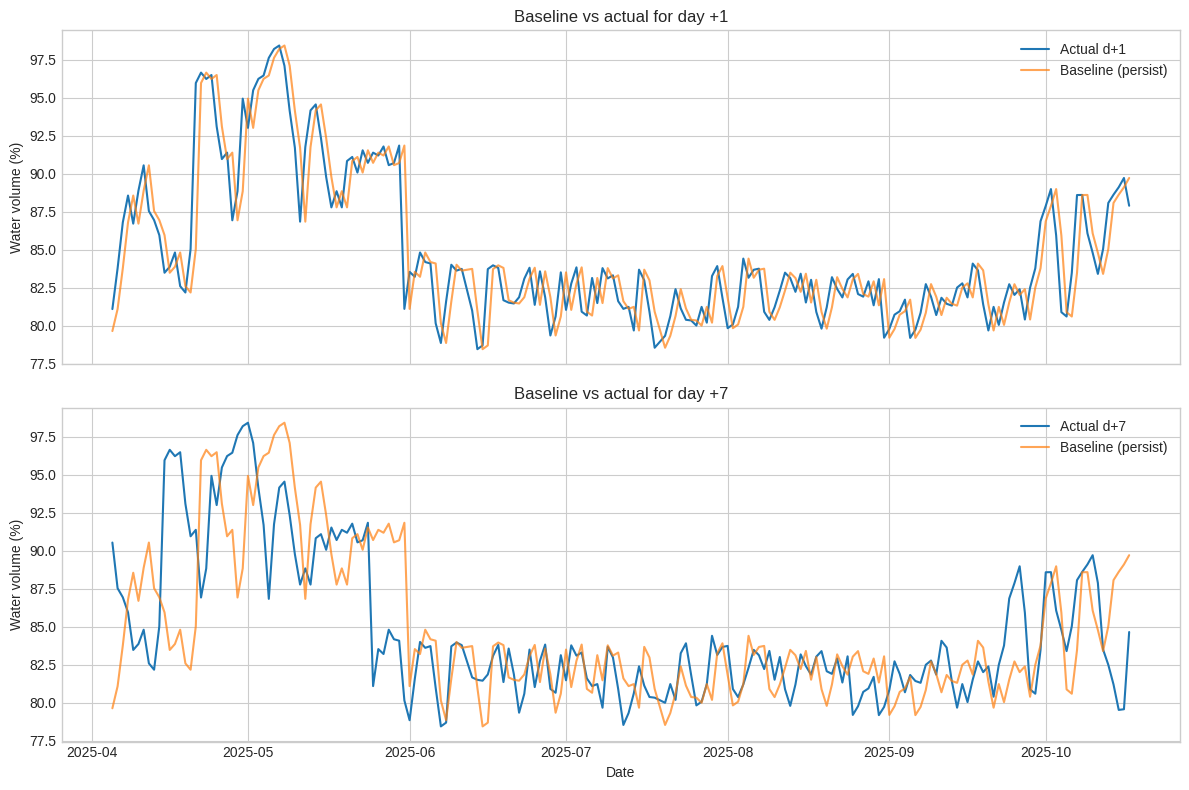

In [49]:
# Visual check for the shortest and longest horizons
horizons_to_plot = [1, FORECAST_HORIZON_DAYS]

fig, axes = plt.subplots(len(horizons_to_plot), 1, figsize=(12, 8), sharex=True)
if len(horizons_to_plot) == 1:
    axes = [axes]

for ax, horizon in zip(axes, horizons_to_plot):
    col = f"target_volume_d{horizon}"
    ax.plot(df_model["date"].iloc[date_split_index:], Y_test[col].values, label=f"Actual d+{horizon}")
    ax.plot(
        df_model["date"].iloc[date_split_index:],
        baseline_pred[:, horizon - 1],
        label="Baseline (persist)",
        alpha=0.7,
    )
    ax.set_title(f"Baseline vs actual for day +{horizon}")
    ax.set_ylabel("Water volume (%)")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Visual comparison of the baseline prediction

We compare the persistence baseline for the first day ahead and the farthest horizon to show how error grows with lead time.


## 10. Random Forest model (multi-output)

We now fit a multi-output Random Forest that uses historical signals plus the noisy forecasted weather for each day in the horizon.


In [50]:
model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=target_cols, index=Y_test.index)

mae_per_horizon = pd.Series(
    {col: mean_absolute_error(Y_test[col], y_pred_df[col]) for col in target_cols}
)
model_mae = mae_per_horizon.mean()

print("Mean MAE across horizons:", model_mae)
mae_per_horizon


Mean MAE across horizons: 2.3840505804606265


target_volume_d1    1.567154
target_volume_d2    2.162966
target_volume_d3    2.493950
target_volume_d4    2.688961
target_volume_d5    2.672627
target_volume_d6    2.523274
target_volume_d7    2.579423
dtype: float64

### Model performance comparison

We look at MAE per horizon and the average across horizons to see how much the model improves over persistence.


In [51]:
improvement = baseline_mae_series - mae_per_horizon

print("Baseline mean MAE:", baseline_mae_series.mean())
print("Random Forest mean MAE:", model_mae)
print("Mean improvement:", improvement.mean())

pd.DataFrame({
    "baseline_mae": baseline_mae_series,
    "rf_mae": mae_per_horizon,
    "improvement": improvement,
})


Baseline mean MAE: 2.6043865956482115
Random Forest mean MAE: 2.3840505804606265
Mean improvement: 0.22033601518758542


,baseline_mae,rf_mae,improvement
target_volume_d1,1.608344,1.567154,0.041190
target_volume_d2,2.303555,2.162966,0.140589
target_volume_d3,2.773711,2.493950,0.279761
target_volume_d4,2.974603,2.688961,0.285642
target_volume_d5,2.944128,2.672627,0.271501
target_volume_d6,2.763871,2.523274,0.240596
target_volume_d7,2.862495,2.579423,0.283072


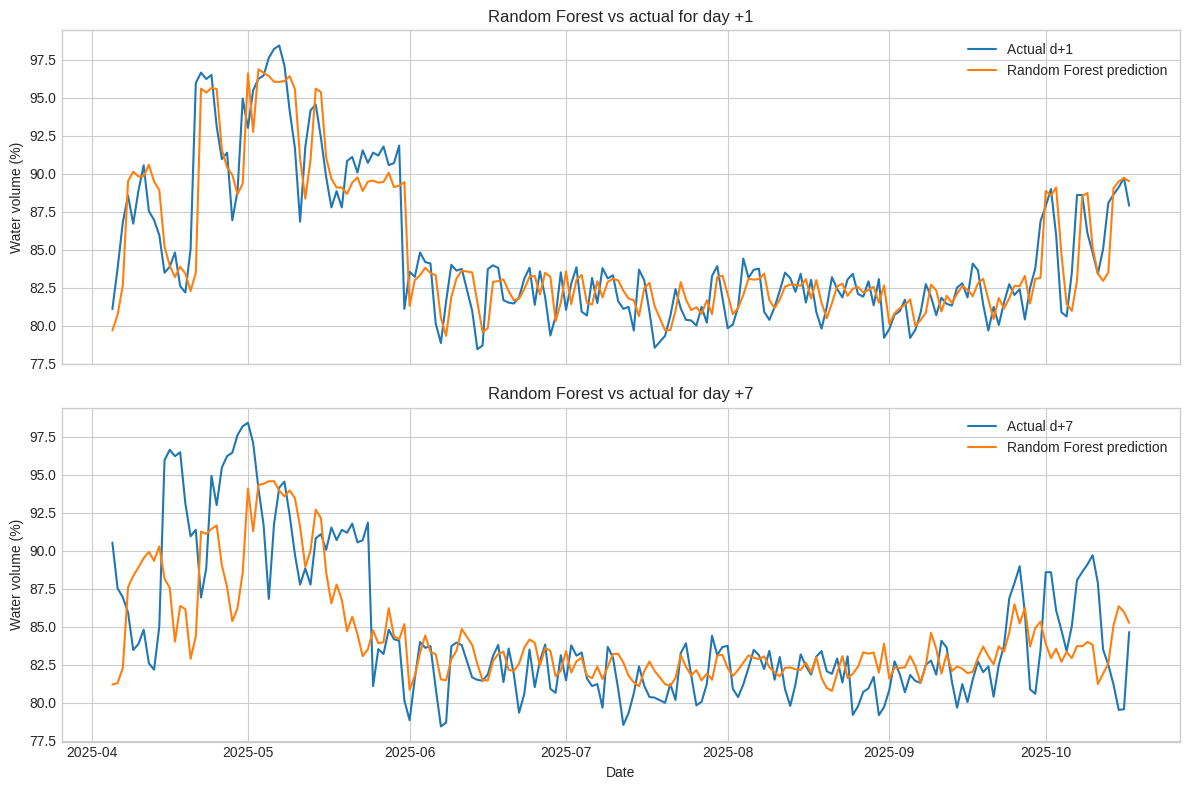

In [52]:
# Plot predictions for the first and last horizons
horizons_to_plot = [1, FORECAST_HORIZON_DAYS]

fig, axes = plt.subplots(len(horizons_to_plot), 1, figsize=(12, 8), sharex=True)
if len(horizons_to_plot) == 1:
    axes = [axes]

for ax, horizon in zip(axes, horizons_to_plot):
    col = f"target_volume_d{horizon}"
    ax.plot(df_model["date"].iloc[date_split_index:], Y_test[col].values, label=f"Actual d+{horizon}")
    ax.plot(
        df_model["date"].iloc[date_split_index:],
        y_pred_df[col].values,
        label="Random Forest prediction",
    )
    ax.set_title(f"Random Forest vs actual for day +{horizon}")
    ax.set_ylabel("Water volume (%)")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Visual comparison: Random Forest vs Actual

The model tracks the near-term horizon closely and degrades gracefully for farther horizons, benefiting from the forecasted weather inputs.


## 11. Feature importance analysis

The importances help identify which lagged volumes, rolling rainfall, seasonal markers, and forecasted weather days the model uses most.


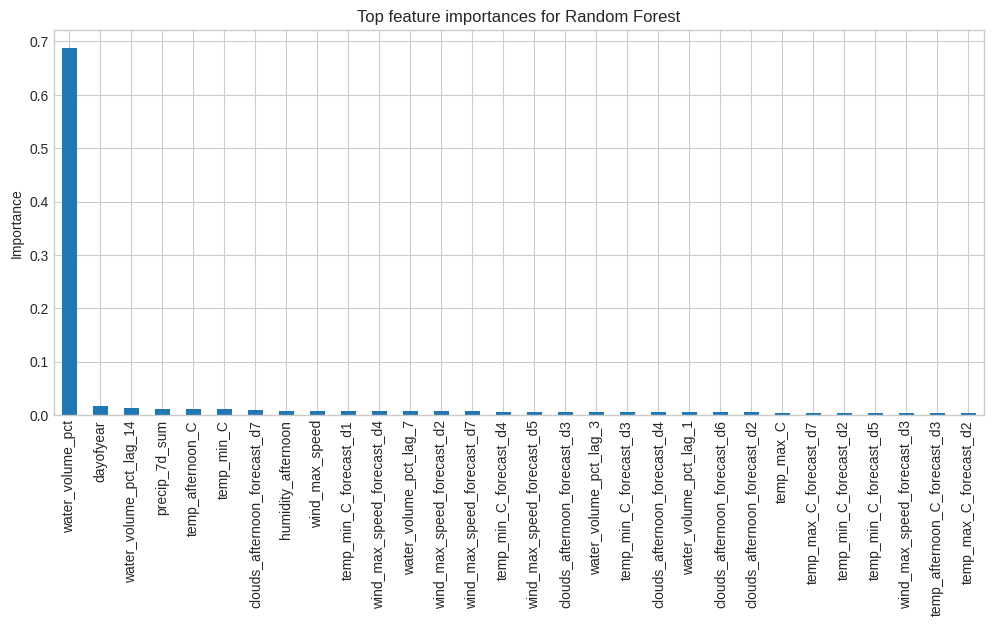

water_volume_pct                  0.687367
dayofyear                         0.016002
water_volume_pct_lag_14           0.012836
precip_7d_sum                     0.011386
temp_afternoon_C                  0.010361
                                    ...   
humidity_afternoon_forecast_d4    0.002607
precip_total_mm_forecast_d4       0.002584
precip_total_mm_forecast_d5       0.002346
clouds_afternoon                  0.001921
precip_total_mm                   0.001791
Length: 66, dtype: float64

In [53]:
fi = pd.Series(model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

plt.figure(figsize=(12,5))
fi_sorted.head(30).plot(kind="bar")
plt.title("Top feature importances for Random Forest")
plt.ylabel("Importance")
plt.show()

fi_sorted


### Key insights from feature importance

Expect lag features to dominate near-term predictions, while forecasted precipitation and temperature features for later days gain importance as the horizon increases.


## 12. Risk-based evaluation (using farthest horizon)

Risk evaluation now focuses on the farthest day in the horizon to check long-range alerting value.


In [54]:
risk_eval_horizon = FORECAST_HORIZON_DAYS


def classify(volume):
    if volume < 20:
        return "dry_risk"
    elif volume > 90:
        return "overflow_risk"
    else:
        return "normal"


df_results = df_model.iloc[date_split_index:].copy()
df_results["y_true"] = Y_test[f"target_volume_d{risk_eval_horizon}"].values
df_results["y_pred"] = y_pred_df[f"target_volume_d{risk_eval_horizon}"].values

df_results["risk_true"] = df_results["y_true"].apply(classify)
df_results["risk_pred"] = df_results["y_pred"].apply(classify)

df_results[["date", "y_true", "y_pred", "risk_true", "risk_pred"]].head()


,date,y_true,y_pred,risk_true,risk_pred
776,2025-04-05,90.550232,81.201199,overflow_risk,normal
777,2025-04-06,87.542045,81.296080,normal,normal
778,2025-04-07,86.945485,82.295240,normal,normal
779,2025-04-08,85.955448,87.615279,normal,normal
780,2025-04-09,83.480358,88.351658,normal,normal


### Risk classification accuracy

Accuracy is computed on the longest horizon, since that is the most challenging use case for early-warning scenarios.


In [55]:
risk_accuracy = (df_results["risk_true"] == df_results["risk_pred"]).mean()
risk_accuracy


np.float64(0.8505154639175257)

### Confusion matrix for risk states

Checking where the model errs for long-range predictions helps prioritize mitigation strategies.


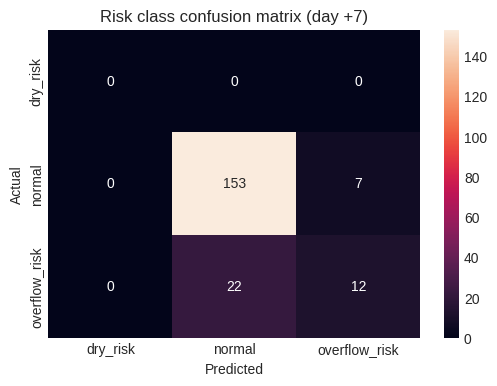

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_results["risk_true"], df_results["risk_pred"],
                      labels=["dry_risk", "normal", "overflow_risk"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["dry_risk", "normal", "overflow_risk"],
            yticklabels=["dry_risk", "normal", "overflow_risk"])
plt.title(f"Risk class confusion matrix (day +{risk_eval_horizon})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
